In [39]:
!nvidia-smi

Mon Apr 13 12:32:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [40]:
import os
HOME = os.getcwd()
print(HOME)

/content/datasets/datasets


## Install dependencies

In [41]:
!pip install -q ultralytics roboflow

## Imports

In [42]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

## Pull dataset

In [43]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("roboflow-jvuqo").project("football-field-detection-f07vi")
version = project.version(12)
dataset = version.download("yolov8")

mkdir: cannot create directory ‘/content/datasets/datasets/datasets’: File exists
/content/datasets/datasets/datasets
loading Roboflow workspace...
loading Roboflow project...


**NOTE:** Update `data.yaml` structure to align with the latest requirements of the `ultralytics` package.

In [44]:
!sed -i 's|\(train: \).*|\1../train/images|' {dataset.location}/data.yaml
!sed -i 's|\(val: \).*|\1../valid/images|' {dataset.location}/data.yaml

## Custom training

In [45]:
%cd {HOME}

!yolo task=pose mode=train model=yolov8n-pose.pt data={dataset.location}/data.yaml batch=16 epochs=100 imgsz=640 mosaic=0.0 plots=True

/content/datasets/datasets
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/datasets/datasets/football-field-detection-12/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-pose.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=train4, nbs=64, nms=False

In [46]:
!ls {HOME}/runs/pose/train/

args.yaml    train_batch0.jpg	  train_batch1262.jpg  weights
labels.jpg   train_batch1260.jpg  train_batch1.jpg
results.csv  train_batch1261.jpg  train_batch2.jpg


/content/datasets/datasets


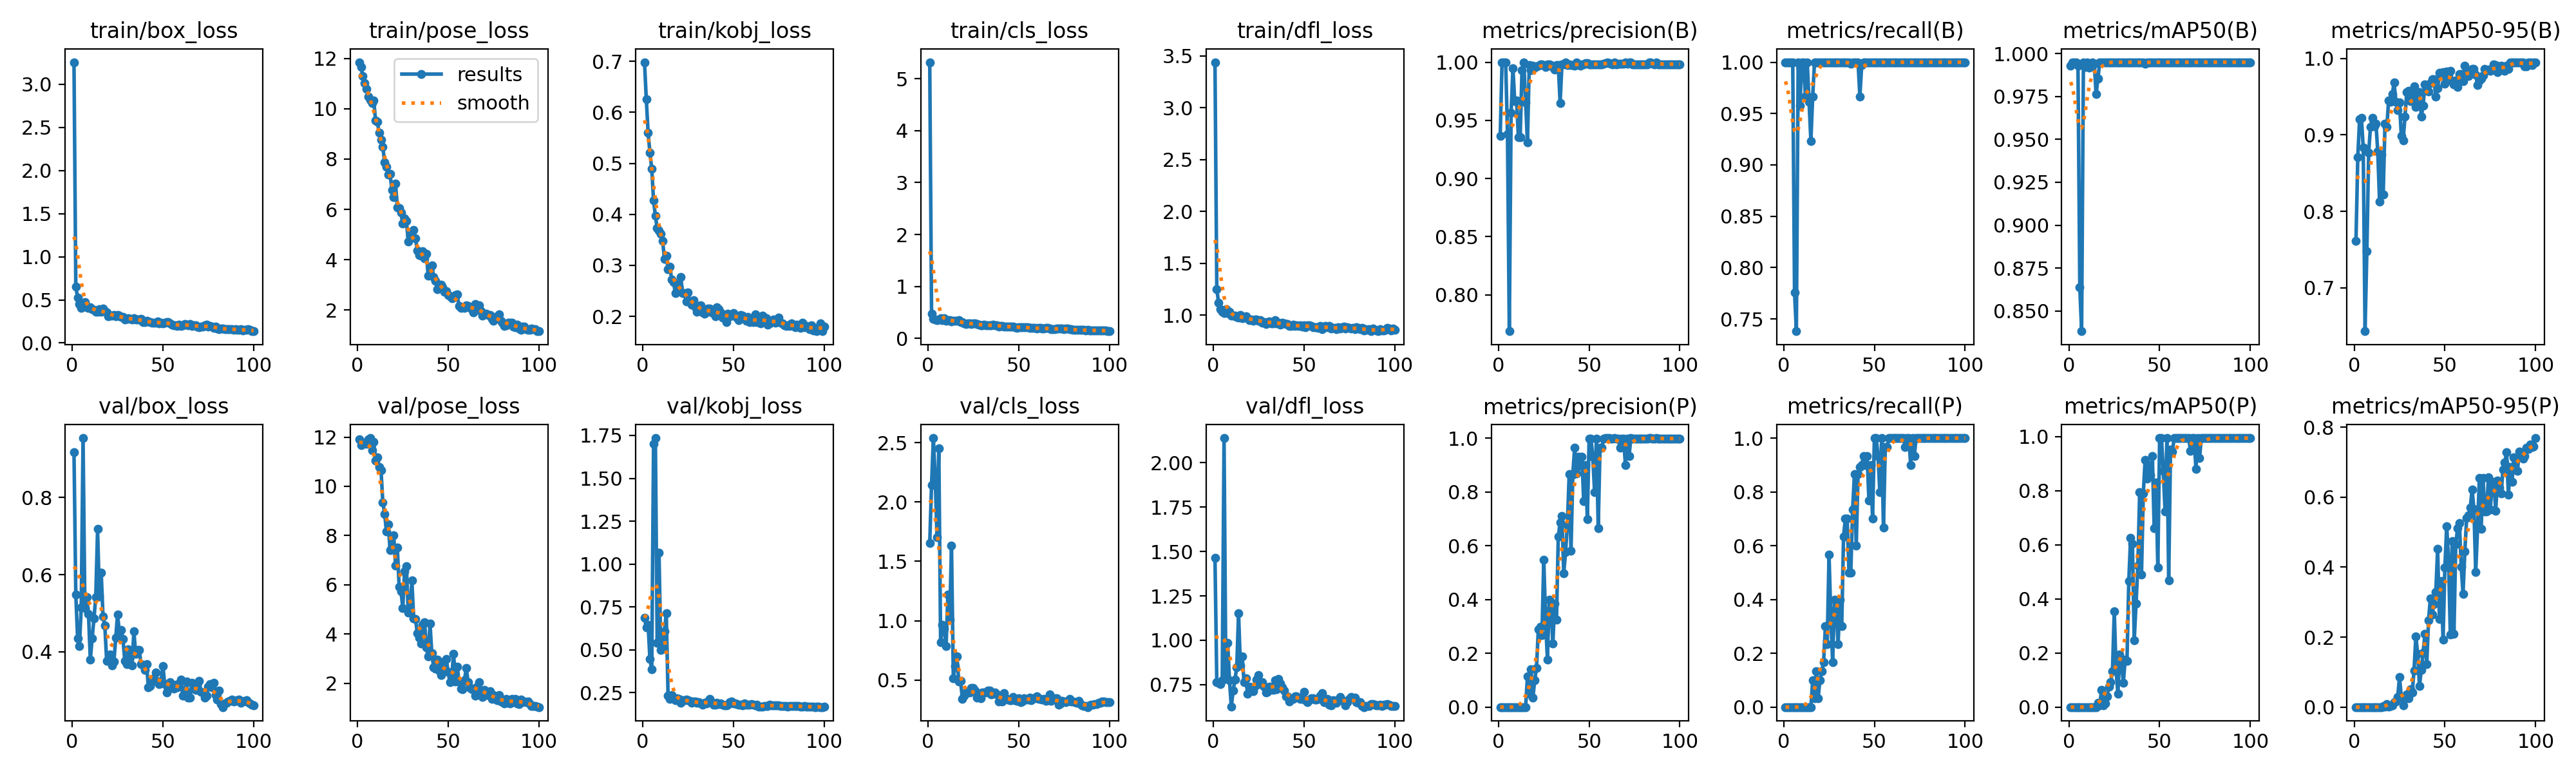

In [48]:
import os
%cd {HOME}

# Correcting the path to 'train4' where the training results were saved
Image(filename=f'{HOME}/runs/pose/train4/results.png', width=600)

/content/datasets/datasets


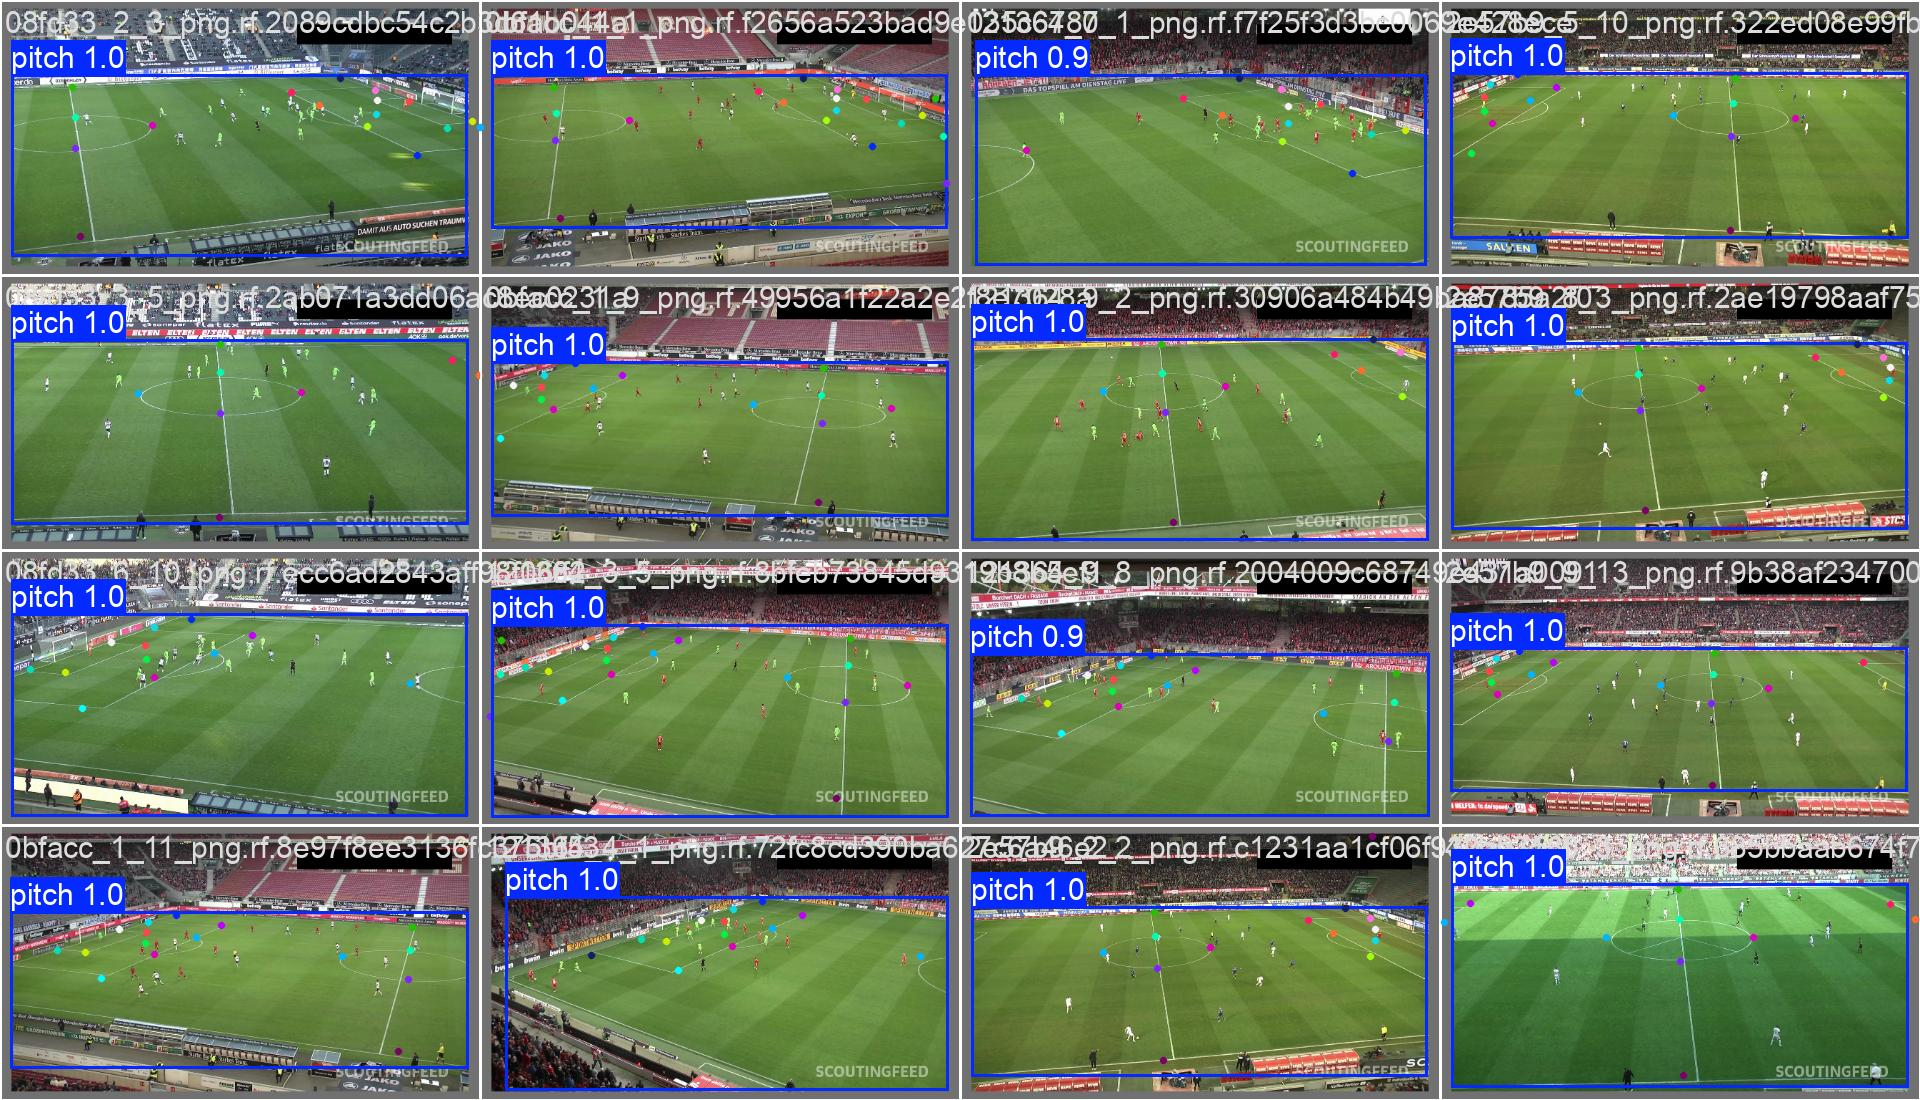

In [50]:
%cd {HOME}
Image(filename=f'{HOME}/runs/pose/train4/val_batch0_pred.jpg', width=600)

## Validate custom model

In [51]:
%cd {HOME}

!yolo task=pose mode=val model={HOME}/runs/pose/train/weights/best.pt data={dataset.location}/data.yaml

/content/datasets/datasets
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x-pose summary (fused): 122 layers, 69,784,275 parameters, 0 gradients, 264.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3004.0±544.1 MB/s, size: 254.4 KB)
val: Scanning /content/datasets/datasets/datasets/football-field-detection-12/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 5.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.6s
                   all         30         30      0.998          1      0.995      0.966      0.998          1      0.995      0.397
Speed: 2.7ms preprocess, 35.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/datasets/datasets/runs/pose/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Deploy model on Roboflow

In [54]:
!yolo export \
       model={HOME}/runs/pose/train/weights/best.pt \
       format=onnx \
       imgsz=640

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv8x-pose summary (fused): 122 layers, 69,784,275 parameters, 0 gradients, 264.7 GFLOPs

PyTorch: starting from '/content/datasets/datasets/runs/pose/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 101, 8400) (533.3 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 29.6s, saved as '/content/datasets/datasets/runs/pose/train/weights/best.onnx' (266.6 MB)

Export complete (36.5s)
Results saved to /content/datasets/datasets/runs/pose/train/weights
Predict:         yolo predict task=pose model=/content/datasets/datasets/runs/pose/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=pose model=/content/datasets/datasets/runs/pose/train/weights/best.onnx imgsz=640 data=/content/datasets/datasets/datasets/football-field-detection-12/data.yaml  
Visualize:       https://netron.app
💡 Learn 

In [63]:
import os

%cd {HOME}

# Path to the exported ONNX model
MODEL_PATH = f'{HOME}/runs/pose/train/weights/best.onnx'

# Path to a sample image from the validation set of your dataset
# You can change this to your own image path, e.g., 'source=/path/to/your/image.jpg'
SAMPLE_IMAGE_PATH = '/content/datasets/datasets/datasets/football-field-detection-12/test/test_local/key.jpg'

# Check if the sample image exists, if not, try to find another one or inform the user
if not os.path.exists(SAMPLE_IMAGE_PATH):
    # This is a placeholder for more robust image finding if needed
    # For simplicity, we'll proceed assuming this path is correct for the dataset structure
    print(f"Warning: Sample image not found at {SAMPLE_IMAGE_PATH}. Please provide a valid image path for 'source'.")
    # As a fallback, try to list a few images to guide the user
    import glob
    valid_images_dir = f'{dataset.location}/valid/images'
    if os.path.exists(valid_images_dir):
        first_image = glob.glob(f'{valid_images_dir}/*.jpg') + glob.glob(f'{valid_images_dir}/*.jpeg') + glob.glob(f'{valid_images_dir}/*.png')
        if first_image:
            SAMPLE_IMAGE_PATH = first_image[0]
            print(f"Using sample image: {SAMPLE_IMAGE_PATH}")
        else:
            print(f"No images found in {valid_images_dir}.")
    else:
        print(f"Validation images directory not found at {valid_images_dir}.")

# Run prediction with the ONNX model
!yolo task=pose mode=predict model='{MODEL_PATH}' source='{SAMPLE_IMAGE_PATH}' imgsz=640 conf=0.25

/content/datasets/datasets
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/datasets/datasets/runs/pose/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
2026-04-13 13:28:28.409726843 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 4 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.

image 1/1 /content/datasets/datasets/datasets/football-field-detection-12/test/test_local/key.jpg: 640x640 1 pitch, 103.8ms
Speed: 4.4ms preprocess, 103.8ms inference, 16.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/datasets/datasets/runs/pose/predict5
💡 Learn more at https://docs.ultralytics.com/modes/predict


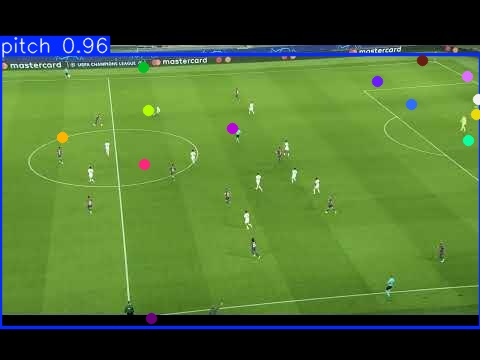

In [65]:
import glob
from IPython.display import Image, display

# Find the generated prediction image in the predict4 directory
predict_dir = f'{HOME}/runs/pose/predict5'
predicted_image_paths = glob.glob(f'{predict_dir}/*.jpg') + glob.glob(f'{predict_dir}/*.jpeg') + glob.glob(f'{predict_dir}/*.png')

if predicted_image_paths:
    # Assuming there's only one relevant image generated, or taking the first one
    display(Image(filename=predicted_image_paths[0], width=600))
else:
    print(f"No prediction images found in {predict_dir}")

In [68]:
%cd {HOME}

VIDEO_PATH = '/content/datasets/datasets/datasets/football-field-detection-12/test/test_local/match.mp4'
OUTPUT_DIR = f'{HOME}/runs/pose/predict_video'

# Run prediction on the video
!yolo task=pose mode=predict model='{MODEL_PATH}' source='{VIDEO_PATH}' imgsz=640 conf=0.25 project={OUTPUT_DIR} name=match_prediction save=True

import os
from IPython.display import Video, display

# Find the predicted video file
# The yolo command saves to a subdirectory within the specified project/name
predicted_video_dir = f'{OUTPUT_DIR}/match_prediction2'
predicted_video_path = f'{predicted_video_dir}/match.avi'

print(f"Checking for video in: {predicted_video_dir}")
if os.path.exists(predicted_video_dir):
    print(f"Contents of {predicted_video_dir}:")
    !ls -lh {predicted_video_dir}

if os.path.exists(predicted_video_path):
    display(Video(predicted_video_path, width=800))
else:
    print(f"Predicted video not found at {predicted_video_path}")
    print("Please check the output logs and the directory listing above for the exact save location.")

/content/datasets/datasets
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/datasets/datasets/runs/pose/train/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CUDAExecutionProvider
2026-04-13 13:35:53.308450457 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 4 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.

video 1/1 (frame 1/750) /content/datasets/datasets/datasets/football-field-detection-12/test/test_local/match.mp4: 640x640 1 pitch, 83.6ms
video 1/1 (frame 2/750) /content/datasets/datasets/datasets/football-field-detection-12/test/test_local/match.mp4: 640x640 1 pitch, 83.6ms
video 1/1 (frame 3/750) /content/datasets/datasets/datasets/football-field-detection-12/test/test_local/match.mp4: 640x640 1 pitch,